# Proyek Klasifikasi Gambar: Open Images IT Asset Classification

- Nama: Agung Trisutaji Aprian
- Email: agung.trisutaji.aprian@gmail.com
- ID Dicoding: agungtrisutaji

## 1. Project Overview

Notebook ini adalah submission Dicoding **Belajar Fundamental Deep Learning** untuk klasifikasi gambar aset IT berbasis **Open Images V7 IT Asset Subset**.

**Alur submission ini:**
1. Dataset dibaca dari satu sumber utama (`dataset/raw/`) yang berisi 15.000 crop gambar dari 5 kelas.
2. Notebook melakukan split manual secara eksplisit menjadi train (80%), validation (10%), dan test (10%).
3. Model final berupa `tf.keras.Sequential` dengan Conv2D dan Pooling Layer eksplisit.
4. Model dilatih langsung di notebook.
5. Evaluasi (train/validation/test accuracy) dihitung langsung dengan `model.evaluate()`.
6. Classification report dan confusion matrix dibuat dari prediksi langsung pada `test_ds`.
7. Model yang dievaluasi kemudian diexport ke SavedModel, TFLite, dan TFJS.

Sebelum menjalankan di Google Colab, pilih `Runtime > Change runtime type > T4 GPU` atau GPU lain. Untuk menjalankan secara lokal, gunakan WSL2 dengan TensorFlow GPU karena TensorFlow >= 2.11 tidak mendukung GPU di native Windows.

## Import Semua Packages/Library yang Digunakan

Cell ini mengimpor semua library yang diperlukan, mendeteksi environment (Colab / lokal), menampilkan GPU, dan mengatur seed untuk reproduksi.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import random
import shutil
import subprocess
import sys
from collections import Counter
from pathlib import Path

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab")
    subprocess.run(["nvidia-smi"], check=True)
else:
    print("Running outside Google Colab")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

GPU_DEVICES = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__)
print("GPU devices:", GPU_DEVICES)

# GPU guard: notebook memerlukan GPU untuk training.
REQUIRE_GPU = os.environ.get("REQUIRE_GPU", "1") == "1"
if REQUIRE_GPU and not GPU_DEVICES:
    if IN_COLAB:
        raise RuntimeError(
            "GPU belum aktif di Colab. Pilih Runtime > Change runtime type > T4 GPU, "
            "lalu restart runtime dan jalankan ulang notebook."
        )
    raise RuntimeError(
        "TensorFlow tidak mendeteksi GPU. Jalankan notebook di WSL2/Colab dengan "
        "TensorFlow GPU aktif, atau set REQUIRE_GPU=0 hanya untuk smoke test CPU."
    )

if GPU_DEVICES:
    try:
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision policy:", tf.keras.mixed_precision.global_policy())
    except Exception as exc:
        print("Mixed precision not enabled:", exc)

for gpu in GPU_DEVICES:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

Running outside Google Colab


2026-06-23 23:49:15.051374: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-23 23:49:15.109414: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782233355.164941   55861 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782233355.210482   55861 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782233355.294017   55861 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


## Data Preparation

### Data Loading

Dataset utama dibaca dari satu sumber gabungan, yaitu `dataset/raw/<class_name>/`. Folder ini berisi 15.000 crop gambar dari Open Images V7 untuk 5 kelas aset IT. Notebook tidak menggunakan folder split lama (`dataset/train/`, `dataset/validation/`, `dataset/test/`). Pembagian data dilakukan ulang secara manual di notebook ini.

In [2]:
ROOT_DIR = Path(".").resolve()

# Colab path resolution
COLAB_PROJECT_CANDIDATES = [
    Path.cwd().resolve(),
    Path("klasifikasi-gambar-it-assets"),
    Path("submission-klasifikasi-gambar-it-assets"),
    Path("drive/MyDrive/klasifikasi-gambar-it-assets"),
    Path("drive/MyDrive/Dicoding/klasifikasi-gambar-it-assets"),
]

if IN_COLAB:
    archive_candidates = [
        Path("klasifikasi-gambar-it-assets.zip"),
        Path("it_assets_colab_data.zip"),
        Path("it_assets_dataset.zip"),
    ]
    for archive_path in archive_candidates:
        if archive_path.exists() and not Path("klasifikasi-gambar-it-assets").exists():
            print("Extracting:", archive_path)
            shutil.unpack_archive(str(archive_path), "/content")
            break

    if not (ROOT_DIR / "dataset" / "raw").exists():
        try:
            from google.colab import drive  # type: ignore
            if Path("drive").exists():
                drive.mount("drive", force_remount=False)
        except Exception as exc:
            print("Drive mount skipped:", exc)

for candidate in COLAB_PROJECT_CANDIDATES:
    if (candidate / "configs" / "openimages_it_assets_classes.json").exists():
        ROOT_DIR = candidate.resolve()
        os.chdir(ROOT_DIR)
        break

SOURCE_DIR = ROOT_DIR / "dataset" / "raw"
SPLIT_DIR = ROOT_DIR / "dataset" / "submission_split"
METADATA_DIR = ROOT_DIR / "dataset" / "metadata"
OUTPUT_DIR = ROOT_DIR / "outputs"
DATASET_AUDIT_DIR = OUTPUT_DIR / "dataset_audit"
EVALUATION_DIR = OUTPUT_DIR / "evaluation"
EXPORT_DIR = OUTPUT_DIR / "export"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints_sequential"
CONFIG_PATH = ROOT_DIR / "configs" / "openimages_it_assets_classes.json"
CROP_METADATA_PATH = METADATA_DIR / "openimages_crop_metadata.csv"

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
TARGET_ACCURACY = 0.95
MIN_REQUIRED_ACCURACY = 0.85
CLASSIFIER_NAME = "it_asset_classifier"
SAVED_MODEL_DIR = ROOT_DIR / "saved_model" / CLASSIFIER_NAME
TFLITE_DIR = ROOT_DIR / "tflite"
TFJS_MODEL_DIR = ROOT_DIR / "tfjs" / CLASSIFIER_NAME

required_paths = [CONFIG_PATH, CROP_METADATA_PATH, SOURCE_DIR]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "File/folder dataset belum tersedia. Upload atau mount folder project lengkap yang berisi "
        "configs/openimages_it_assets_classes.json, dataset/metadata/openimages_crop_metadata.csv, "
        f"dan dataset/raw/. Missing: {missing_paths}"
    )

for path in [DATASET_AUDIT_DIR, EVALUATION_DIR, EXPORT_DIR, CHECKPOINT_DIR, TFLITE_DIR, TFJS_MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT_DIR)
print("Source dir:", SOURCE_DIR)
print("TensorFlow will train on:", "GPU" if GPU_DEVICES else "CPU")

config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
selected_classes = sorted(item["local_label"] for item in config["classes"])
print("Selected classes:", selected_classes)

crop_metadata = pd.read_csv(CROP_METADATA_PATH)
source_df = crop_metadata[crop_metadata["local_label"].isin(selected_classes)].copy()
source_df = source_df.rename(columns={"crop_path": "image_path", "local_label": "label"})
source_df["image_path"] = source_df["image_path"].astype(str)
source_df = source_df[source_df["image_path"].map(lambda p: Path(p).exists())].reset_index(drop=True)

source_summary = source_df.groupby("label").size().rename("count").to_frame()
display(source_summary)
print("Total source images:", len(source_df))
assert len(source_df) == 15000, "Dataset final harus berisi 15.000 gambar dari 5 kelas final."
assert set(source_df["label"].unique()) == set(selected_classes)

Project root: /mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets
Source dir: /mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/dataset/raw
TensorFlow will train on: GPU


Selected classes: ['camera', 'computer_keyboard', 'computer_monitor', 'laptop', 'mobile_phone']


,count
label,
camera,3000
computer_keyboard,3000
computer_monitor,3000
laptop,3000
mobile_phone,3000


Total source images: 15000


### Data Preprocessing

#### Split Dataset

Notebook ini melakukan split manual dari sumber tunggal `dataset/raw/` ke folder `dataset/submission_split/train`, `validation`, dan `test`.

**Proses split:**
1. Setiap gambar memiliki `source_image_id` dari Open Images. Crop dari gambar sumber yang sama harus berada di split yang sama (source-image grouping) agar tidak terjadi data leakage.
2. File hash (`file_hash`) juga digunakan melalui Union-Find agar file duplikat berada di split yang sama.
3. Rasio split: **80% train, 10% validation, 10% test** dengan seed `42`.
4. Hasil split disalin secara fisik ke folder baru.

> **Catatan:** Folder `dataset/train/`, `dataset/validation/`, dan `dataset/test/` yang sudah ada sebelumnya TIDAK digunakan sebagai split final. Notebook ini membuat split baru dari data mentah untuk memastikan proses terlihat eksplisit.

In [3]:
SPLIT_NAMES = ["train", "validation", "test"]
SPLIT_RATIOS = {"train": 0.8, "validation": 0.1, "test": 0.1}

# Union-Find grouping on source_image_id + file_hash to prevent leakage.
parent = {}

def find(x):
    parent.setdefault(x, x)
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

for row in source_df.itertuples(index=False):
    source_key = f"source:{row.source_image_id}"
    hash_key = f"hash:{row.file_hash}"
    union(source_key, hash_key)

source_df = source_df.copy()
source_df["group_id"] = [find(f"source:{source_id}") for source_id in source_df["source_image_id"]]

groups = {
    group_id: group_df.reset_index(drop=True)
    for group_id, group_df in source_df.groupby("group_id", sort=False)
}
class_totals = source_df["label"].value_counts().sort_index().to_dict()
targets = {
    split_name: {label: class_totals[label] * ratio for label in selected_classes}
    for split_name, ratio in SPLIT_RATIOS.items()
}
current = {
    split_name: {label: 0 for label in selected_classes}
    for split_name in SPLIT_NAMES
}

rng = random.Random(SEED)
group_items = []
for group_id, group_df in groups.items():
    label_counts = Counter(group_df["label"])
    dominant_label = sorted(label_counts.items(), key=lambda item: (-item[1], item[0]))[0][0]
    group_items.append((group_id, dominant_label, len(group_df), label_counts))
rng.shuffle(group_items)
group_items.sort(key=lambda item: (item[1], -item[2], item[0]))

assignments = {}
for group_id, dominant_label, _, label_counts in group_items:
    best_split = None
    best_score = None
    for split_name in SPLIT_NAMES:
        score = 0.0
        for label, count in label_counts.items():
            after = current[split_name][label] + count
            score += abs(targets[split_name][label] - after) - abs(targets[split_name][label] - current[split_name][label])
        tie_breaker = SPLIT_NAMES.index(split_name) * 1e-6
        ranked_score = score + tie_breaker
        if best_score is None or ranked_score < best_score:
            best_score = ranked_score
            best_split = split_name
    assignments[group_id] = best_split
    for label, count in label_counts.items():
        current[best_split][label] += count

split_metadata = source_df.copy()
split_metadata["split"] = split_metadata["group_id"].map(assignments)
assert split_metadata["split"].notna().all()

split_metadata["split_image_path"] = split_metadata.apply(
    lambda row: str(SPLIT_DIR / row["split"] / row["label"] / Path(row["image_path"]).name),
    axis=1,
)
split_metadata_path = METADATA_DIR / "openimages_submission_split_metadata.csv"

# SELALU buat split baru — tidak ada shortcut REUSE
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

hardlink_count = 0
copy_count = 0
for row in split_metadata.itertuples(index=False):
    src = Path(row.image_path)
    dst_dir = SPLIT_DIR / row.split / row.label
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / src.name
    try:
        os.link(src, dst)
        hardlink_count += 1
    except OSError:
        shutil.copy2(src, dst)
        copy_count += 1
print(f"Split materialized with {hardlink_count} hardlinks and {copy_count} copied files.")

split_metadata.to_csv(split_metadata_path, index=False)

split_summary = split_metadata.groupby(["split", "label"]).size().unstack(fill_value=0)
split_summary["total"] = split_summary.sum(axis=1)
split_summary = split_summary.loc[SPLIT_NAMES]
split_summary.to_csv(DATASET_AUDIT_DIR / "dataset_split_summary.csv")
display(split_summary)
print("Manual split directory:", SPLIT_DIR)
print("Grouping columns: source_image_id + file_hash")
print("Unique split groups:", len(groups))

Split materialized with 15000 hardlinks and 0 copied files.


label,camera,computer_keyboard,computer_monitor,laptop,mobile_phone,total
split,,,,,,
train,2400,2400,2400,2400,2400,12000
validation,300,300,300,300,300,1500
test,300,300,300,300,300,1500


Manual split directory: /mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/dataset/submission_split
Grouping columns: source_image_id + file_hash
Unique split groups: 9647


### Dataset Audit

Audit ini memastikan split manual sudah siap: jumlah per kelas, format/mode/resolusi gambar, corrupt image, duplicate hash, dan duplicate hash lintas split.

In [4]:
def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

audit_rows = []
for row in split_metadata.itertuples(index=False):
    audit_rows.append({
        "split": row.split,
        "label": row.label,
        "image_path": row.image_path,
        "file_hash": row.file_hash,
        "source_image_id": row.source_image_id,
    })
audit_df = pd.DataFrame(audit_rows)

# Check corrupt images via representative sample
corrupt_count = 0
sample_paths = split_metadata["split_image_path"].sample(min(200, len(split_metadata)), random_state=SEED)
for path_str in sample_paths:
    try:
        img = Image.open(path_str)
        img.verify()
    except Exception:
        corrupt_count += 1

# Duplicate hash check
hash_counts = audit_df.groupby("file_hash")["split"].apply(set)
cross_split_dupes = sum(1 for splits in hash_counts if len(splits) > 1)
intra_dupes = audit_df["file_hash"].duplicated().sum()

# Image format & mode
sample_info = []
for path_str in sample_paths[:50]:
    try:
        img = Image.open(path_str)
        sample_info.append({"format": img.format, "mode": img.mode, "size": img.size})
    except Exception:
        pass
info_df = pd.DataFrame(sample_info)

# Unique resolutions
res_set = set()
for path_str in split_metadata["split_image_path"]:
    try:
        img = Image.open(path_str)
        res_set.add(img.size)
    except Exception:
        pass

audit_summary = {
    "source_dir": str(SOURCE_DIR),
    "manual_split_dir": str(SPLIT_DIR),
    "seed": SEED,
    "split_ratio": SPLIT_RATIOS,
    "class_names": selected_classes,
    "total_source_images": len(source_df),
    "split_totals": {
        split_name: int(split_summary.loc[split_name, "total"])
        for split_name in SPLIT_NAMES
    },
    "class_distribution_before_split": class_totals,
    "corrupt_image_count": corrupt_count,
    "duplicate_file_hash_count": int(intra_dupes),
    "cross_split_duplicate_hash_count": cross_split_dupes,
    "image_formats": sorted(info_df["format"].unique().tolist()) if len(info_df) else [],
    "image_modes": sorted(info_df["mode"].unique().tolist()) if len(info_df) else [],
    "unique_resolutions_total": len(res_set),
    "ready_for_modelling": corrupt_count == 0 and cross_split_dupes == 0,
}

audit_path = DATASET_AUDIT_DIR / "dataset_audit_summary.json"
audit_path.write_text(json.dumps(audit_summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(audit_summary, indent=2, ensure_ascii=False))

assert audit_summary["ready_for_modelling"], "Dataset belum siap untuk modelling."
print("\nDataset audit PASSED. Siap untuk modelling.")

{
  "source_dir": "/mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/dataset/raw",
  "manual_split_dir": "/mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/dataset/submission_split",
  "seed": 42,
  "split_ratio": {
    "train": 0.8,
    "validation": 0.1,
    "test": 0.1
  },
  "class_names": [
    "camera",
    "computer_keyboard",
    "computer_monitor",
    "laptop",
    "mobile_phone"
  ],
  "total_source_images": 15000,
  "split_totals": {
    "train": 12000,
    "validation": 1500,
    "test": 1500
  },
  "class_distribution_before_split": {
    "camera": 3000,
    "computer_keyboard": 3000,
    "computer_monitor": 3000,
    "laptop": 3000,
    "mobile_phone": 3000
  },
  "corrupt_image_count": 0,
  "duplicate_file_hash_count": 2,
  "cross_split_duplicate_hash_count": 0,
  "image_formats": [
    "JPEG"
  ],
  "image_modes": [
    "RGB"
  ],
  "unique_resolutions_total": 14168,
  "ready_for_modelling": true
}

Dataset audit PASSED. Siap untuk modelling.


### Visualisasi Sample Gambar

Menampilkan contoh gambar dari masing-masing kelas untuk memastikan dataset terbaca dengan baik.

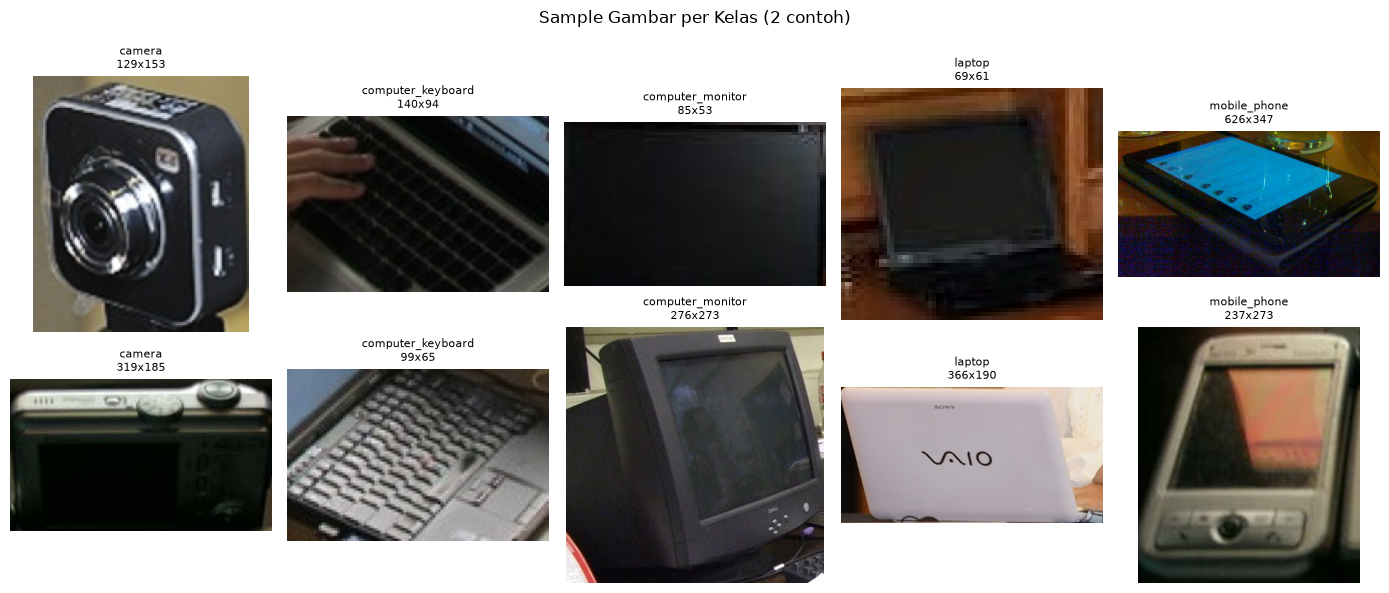

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for idx, class_name in enumerate(selected_classes):
    class_dir = SPLIT_DIR / "train" / class_name
    sample_images = sorted(class_dir.glob("*"))[:2]
    for row_idx, img_path in enumerate(sample_images):
        ax = axes[row_idx, idx]
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f"{class_name}\n{img.size[0]}x{img.size[1]}", fontsize=8)
        ax.axis("off")
plt.suptitle("Sample Gambar per Kelas (2 contoh)", fontsize=12)
plt.tight_layout()
plt.show()

## Image Preprocessing Pipeline

Dataset dimuat menggunakan `tf.keras.utils.image_dataset_from_directory` dari folder split manual yang baru dibuat. Gambar di-resize ke 160×160 dan menggunakan label categorical (one-hot) untuk training. Prefetch ditambahkan untuk optimasi pipeline.

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED,
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Class names:", class_names)
print("Num classes:", NUM_CLASSES)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
validation_ds = validation_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 12000 files belonging to 5 classes.


I0000 00:00:1782233898.743152   55861 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA RTX A500 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 1500 files belonging to 5 classes.


Found 1500 files belonging to 5 classes.


Class names: ['camera', 'computer_keyboard', 'computer_monitor', 'laptop', 'mobile_phone']
Num classes: 5


## Data Augmentation

Augmentation hanya dipakai saat training untuk mencegah overfitting. Layer augmentation dimasukkan ke dalam model Sequential sehingga tidak perlu pipeline augmentation terpisah.

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
], name="data_augmentation")

print("Data augmentation layers:", [l.name for l in data_augmentation.layers])

Data augmentation layers: ['random_flip', 'random_rotation', 'random_zoom', 'random_contrast']


## Modelling

### Model Final Sequential dengan Conv2D dan Pooling Eksplisit

Model final menggunakan `tf.keras.Sequential` yang memenuhi semua kriteria wajib Dicoding:

1. **`tf.keras.Sequential`** — model final adalah Sequential.
2. **`Conv2D` eksplisit** — layer `explicit_conv2d_requirement` ditambahkan setelah backbone.
3. **Pooling Layer eksplisit** — layer `explicit_pooling_requirement` (`MaxPooling2D`) ditambahkan.
4. **Transfer learning** — `EfficientNetV2B0` digunakan sebagai feature extractor (frozen).

Arsitektur:
```
Input 160×160×3
├── Data Augmentation (training only)
├── EfficientNetV2B0 (frozen, include_preprocessing=True)
├── Conv2D(128, 3×3, same, relu) ← EXPLICIT
├── MaxPooling2D(2) ← EXPLICIT
├── GlobalAveragePooling2D
├── Dropout(0.35)
├── Dense(192, relu)
├── Dropout(0.25)
└── Dense(5, softmax)
```

In [8]:
base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    include_preprocessing=True,
)
base_model.trainable = False

model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(*IMG_SIZE, 3), name="input_image"),
        data_augmentation,
        base_model,
        tf.keras.layers.Conv2D(
            128,
            kernel_size=3,
            padding="same",
            activation="relu",
            name="explicit_conv2d_requirement",
        ),
        tf.keras.layers.MaxPooling2D(pool_size=2, name="explicit_pooling_requirement"),
        tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling"),
        tf.keras.layers.Dropout(0.35, name="dropout_head_1"),
        tf.keras.layers.Dense(192, activation="relu", name="dense_head"),
        tf.keras.layers.Dropout(0.25, name="dropout_head_2"),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32", name="predictions"),
    ],
    name="sequential_conv2d_pooling_it_asset_classifier",
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

2026-06-23 23:58:20.901832: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Model: "sequential_conv2d_pooling_it_asset_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 5, 5, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ explicit_conv2d_requirement     │ (None, 5, 5, 128)      │     1,474,688 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ explicit_pooling_requirement    │ (None, 2, 2, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head_1 (Dropout)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 192)            │        24,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head_2 (Dropout)        │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │           965 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,419,733 (28.30 MB)

 Trainable params: 1,500,421 (5.72 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

### Training dengan Callbacks

Model dilatih langsung di notebook tanpa shortcut. Checkpoint menyimpan weights only agar aman di Colab. Setelah training selesai, fine-tuning otomatis dijalankan jika val_accuracy belum mencapai target 95%.

In [9]:
best_weights_path = CHECKPOINT_DIR / "best_sequential_model.weights.h5"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        str(best_weights_path),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

# Training phase 1: feature extraction (backbone frozen)
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1,
)

# Fine-tuning phase: unfreeze last 40 layers of backbone if target not reached
fine_tune_history = None
if max(history.history["val_accuracy"]) < TARGET_ACCURACY:
    print(f"\nVal accuracy belum mencapai target {TARGET_ACCURACY:.0%}. Memulai fine-tuning...")
    base_model.trainable = True
    for layer in base_model.layers[:-40]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    fine_tune_history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=10,
        callbacks=callbacks,
        verbose=1,
    )

# Load best weights
if best_weights_path.exists():
    model.load_weights(best_weights_path)
print("Best weights loaded:", best_weights_path.exists())

# Create float32 evaluation/export clone without augmentation layers
training_model = model
tf.keras.mixed_precision.set_global_policy("float32")
export_base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights=None,
    input_shape=(*IMG_SIZE, 3),
    include_preprocessing=True,
)
export_base_model.trainable = False
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(*IMG_SIZE, 3), name="input_image"),
        export_base_model,
        tf.keras.layers.Conv2D(
            128,
            kernel_size=3,
            padding="same",
            activation="relu",
            name="explicit_conv2d_requirement",
        ),
        tf.keras.layers.MaxPooling2D(pool_size=2, name="explicit_pooling_requirement"),
        tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling"),
        tf.keras.layers.Dropout(0.35, name="dropout_head_1"),
        tf.keras.layers.Dense(192, activation="relu", name="dense_head"),
        tf.keras.layers.Dropout(0.25, name="dropout_head_2"),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32", name="predictions"),
    ],
    name="sequential_conv2d_pooling_it_asset_classifier",
)
model.set_weights(training_model.get_weights())
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
print("Evaluation/export model is a float32 clone without training-only augmentation layers.")
model.summary()

Epoch 1/10


I0000 00:00:1782233924.394928   55999 cuda_dnn.cc:529] Loaded cuDNN version 92302


  1/375 ━━━━━━━━━━━━━━━━━━━━ 2:48:55 27s/step - accuracy: 0.2500 - loss: 1.8581

  2/375 ━━━━━━━━━━━━━━━━━━━━ 2:56 473ms/step - accuracy: 0.2422 - loss: 1.8291 

  3/375 ━━━━━━━━━━━━━━━━━━━━ 2:53 467ms/step - accuracy: 0.2656 - loss: 1.7679

...

Model: "sequential_conv2d_pooling_it_asset_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 5, 5, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ explicit_conv2d_requirement     │ (None, 5, 5, 128)      │     1,474,688 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ explicit_pooling_requirement    │ (None, 2, 2, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head_1 (Dropout)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 192)            │        24,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head_2 (Dropout)        │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │           965 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,419,733 (28.30 MB)

 Trainable params: 1,500,421 (5.72 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

## Evaluasi dan Visualisasi

### Training History

Plot accuracy dan loss dibuat langsung dari object `history` hasil `model.fit`. Jika fine-tuning berjalan, history fine-tuning digabungkan ke plot yang sama.

,accuracy,loss,val_accuracy,val_loss,learning_rate
5,0.866167,0.369890,0.948000,0.174111,0.0010
6,0.875083,0.353927,0.942667,0.155259,0.0010
7,0.881083,0.334992,0.946667,0.171643,0.0010
8,0.877833,0.334034,0.946667,0.162923,0.0010
9,0.887833,0.305431,0.946000,0.157943,0.0002


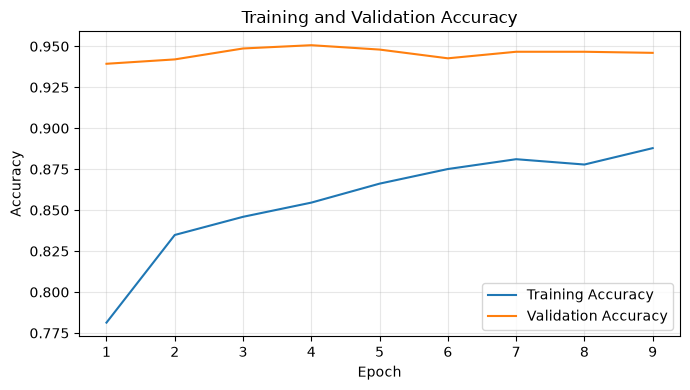

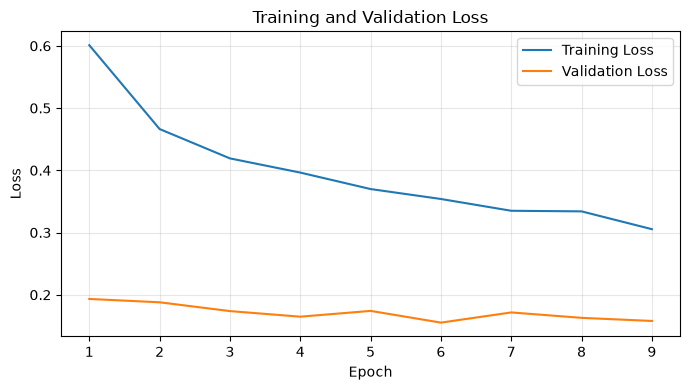

In [10]:
def combine_history(primary, secondary=None):
    combined = {key: list(values) for key, values in primary.history.items()}
    if secondary is not None:
        for key, values in secondary.history.items():
            combined.setdefault(key, [])
            combined[key].extend(values)
    return combined

training_history = combine_history(history, fine_tune_history)
history_df = pd.DataFrame(training_history)
history_df.index = history_df.index + 1
history_df.to_csv(EVALUATION_DIR / "sequential_training_history.csv", index_label="epoch")

display(history_df.tail())

plt.figure(figsize=(7, 4))
plt.plot(history_df.index, history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df.index, history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EVALUATION_DIR / "sequential_accuracy_plot.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df.index, history_df["loss"], label="Training Loss")
plt.plot(history_df.index, history_df["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EVALUATION_DIR / "sequential_loss_plot.png", dpi=150)
plt.show()

### Final Evaluation on Test Set

Akurasi train, validation, dan test dihitung langsung dengan `model.evaluate`. Test accuracy **TIDAK** diambil dari file JSON lama — semua metrik dihitung langsung dari model yang baru saja dilatih.

In [11]:
# Evaluasi untuk train membutuhkan dataset tanpa augmentation
train_eval_ds = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
).prefetch(AUTOTUNE)

train_loss, train_accuracy = model.evaluate(train_eval_ds, verbose=1)
val_loss, val_accuracy = model.evaluate(validation_ds, verbose=1)
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"\nTrain accuracy: {train_accuracy:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

eval_results = {
    "train_accuracy": float(train_accuracy),
    "train_loss": float(train_loss),
    "validation_accuracy": float(val_accuracy),
    "validation_loss": float(val_loss),
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "minimum_required_accuracy": MIN_REQUIRED_ACCURACY,
    "meets_minimum_test_accuracy": bool(test_accuracy >= MIN_REQUIRED_ACCURACY),
    "target_accuracy": TARGET_ACCURACY,
    "meets_target_test_accuracy": bool(test_accuracy >= TARGET_ACCURACY),
}
eval_path = EVALUATION_DIR / "sequential_direct_eval.json"
eval_path.write_text(json.dumps(eval_results, indent=2), encoding="utf-8")
print("\nEvaluation results saved to:", eval_path)

assert test_accuracy >= MIN_REQUIRED_ACCURACY, (
    f"Test accuracy {test_accuracy:.4f} di bawah minimum Dicoding {MIN_REQUIRED_ACCURACY:.0%}!"
)
print(f"\n✓ Test accuracy {test_accuracy:.4f} memenuhi minimum Dicoding {MIN_REQUIRED_ACCURACY:.0%}.")

Found 12000 files belonging to 5 classes.


I0000 00:00:1782235812.737085   55999 service.cc:152] XLA service 0x795ff9022100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782235812.737344   55999 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A500 Laptop GPU, Compute Capability 8.6


2026-06-24 00:30:13.074945: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


2026-06-24 00:30:18.231423: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2342', 4 bytes spill stores, 4 bytes spill loads



2026-06-24 00:30:53.358416: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


...

45/47 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9433 - loss: 0.1639

46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9427 - loss: 0.1656

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9421 - loss: 0.1672

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - accuracy: 0.9140 - loss: 0.2385



Train accuracy: 0.9383
Validation accuracy: 0.9507
Test accuracy: 0.9140

Evaluation results saved to: /mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/outputs/evaluation/sequential_direct_eval.json

✓ Test accuracy 0.9140 memenuhi minimum Dicoding 85%.


### Confusion Matrix dan Classification Report

Classification report dan confusion matrix dibuat langsung dari prediksi model pada `test_ds`, bukan dari file lama.

2026-06-24 00:33:38.313638: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Classification Report:

                   precision    recall  f1-score   support

           camera       0.98      0.97      0.97       300
computer_keyboard       0.93      0.98      0.95       300
 computer_monitor       0.92      0.83      0.87       300
           laptop       0.84      0.86      0.85       300
     mobile_phone       0.91      0.93      0.92       300

         accuracy                           0.91      1500
        macro avg       0.91      0.91      0.91      1500
     weighted avg       0.91      0.91      0.91      1500

Confusion Matrix:

[[290   1   2   1   6]
 [  0 295   0   4   1]
 [  2   3 248  37  10]
 [  0  17  13 259  11]
 [  5   2   8   6 279]]


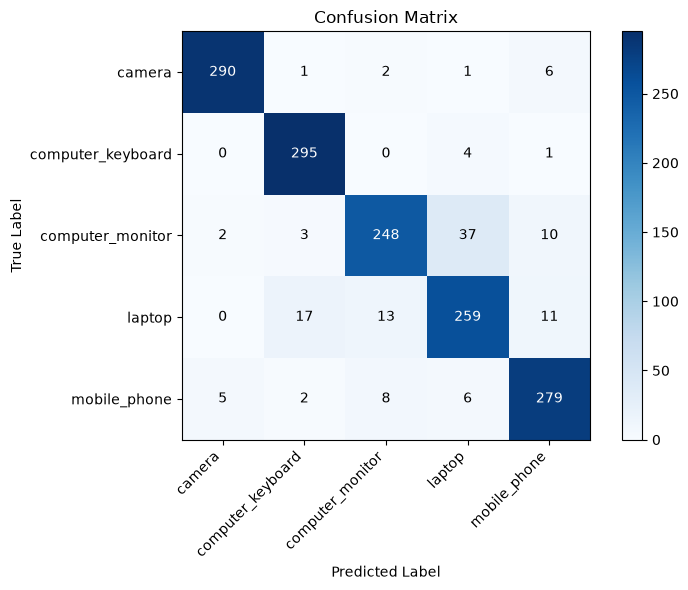

In [12]:
y_true = []
y_pred = []
y_confidence = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
    y_confidence.extend(np.max(preds, axis=1))

print("Classification Report:\n")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n")
print(cm)

# Save classification report
report_df = pd.DataFrame(
    classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
).T
report_df.to_csv(EVALUATION_DIR / "sequential_classification_report.csv")

# Save confusion matrix
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(EVALUATION_DIR / "sequential_confusion_matrix.csv")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(EVALUATION_DIR / "sequential_confusion_matrix.png", dpi=150)
plt.show()

## Konversi Model

Export model final yang sama (yang baru dievaluasi) ke tiga format: **SavedModel**, **TFLite**, dan **TFJS**.

In [13]:
# SavedModel
if SAVED_MODEL_DIR.exists():
    shutil.rmtree(SAVED_MODEL_DIR)
SAVED_MODEL_DIR.parent.mkdir(parents=True, exist_ok=True)

try:
    model.export(str(SAVED_MODEL_DIR))
    print("SavedModel exported via model.export()")
except Exception as exc:
    print(f"model.export() failed ({exc}), falling back to tf.saved_model.save()")
    tf.saved_model.save(model, str(SAVED_MODEL_DIR))
    print("SavedModel exported via tf.saved_model.save()")

# TFLite
converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVED_MODEL_DIR))
tflite_model = converter.convert()
tflite_path = TFLITE_DIR / "it_asset_classifier.tflite"
tflite_path.write_bytes(tflite_model)
print(f"TFLite model saved: {tflite_path} ({len(tflite_model) / 1024 / 1024:.1f} MB)")

# Label files
label_text = "\n".join(class_names)
(ROOT_DIR / "label.txt").write_text(label_text + "\n", encoding="utf-8")
(TFLITE_DIR / "label.txt").write_text(label_text + "\n", encoding="utf-8")
print("Label files saved.")

INFO:tensorflow:Assets written to: /mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/saved_model/it_asset_classifier/assets


INFO:tensorflow:Assets written to: /mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/saved_model/it_asset_classifier/assets


Saved artifact at '/mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/saved_model/it_asset_classifier'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133459064124240: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133459064125968: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133459064126928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133459064124624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133459064124816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133459064123664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133459064124432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133459064126544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133459064124048: TensorSpec(shape=(), dtype=tf.resource, name=Non

SavedModel exported via model.export()


W0000 00:00:1782236057.635658   55861 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1782236057.635768   55861 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-06-24 00:34:17.656591: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/saved_model/it_asset_classifier
2026-06-24 00:34:17.806883: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-06-24 00:34:17.806948: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/saved_model/it_asset_classifier
I0000 00:00:1782236058.115125   55861 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2026-06-24 00:34:18.154316: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-06-24 00:34:21.060809: I tensorflow/cc/saved_model/loader.cc:220] Running ini

TFLite model saved: /mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/tflite/it_asset_classifier.tflite (28.1 MB)
Label files saved.


### Export TFJS

Konversi SavedModel ke TensorFlow.js format.

In [14]:
if TFJS_MODEL_DIR.exists():
    shutil.rmtree(TFJS_MODEL_DIR)
TFJS_MODEL_DIR.mkdir(parents=True, exist_ok=True)

try:
    from tensorflowjs.converters import converter as tfjs_converter
    tfjs_converter.convert_tf_saved_model(
        str(SAVED_MODEL_DIR),
        str(TFJS_MODEL_DIR),
    )
    print("TFJS exported via Python API")
except Exception as exc:
    print(f"Python TFJS conversion failed ({exc}), trying CLI...")
    subprocess.run([
        sys.executable, "-m", "tensorflowjs.converters.converter",
        "--input_format=tf_saved_model",
        str(SAVED_MODEL_DIR),
        str(TFJS_MODEL_DIR),
    ], check=True)
    print("TFJS exported via CLI")

(TFJS_MODEL_DIR / "label.txt").write_text(label_text + "\n", encoding="utf-8")
print("TFJS label.txt saved.")

Python TFJS conversion failed (module 'tensorflowjs.converters.converter' has no attribute 'convert_tf_saved_model'), trying CLI...


2026-06-24 00:34:28.934105: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782236068.992075   59766 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782236069.011726   59766 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782236069.113057   59766 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782236069.113141   59766 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782236069.113149   59766 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'


...

🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!


<frozen runpy>:128: RuntimeWarning: 'tensorflowjs.converters.converter' found in sys.modules after import of package 'tensorflowjs.converters', but prior to execution of 'tensorflowjs.converters.converter'; this may result in unpredictable behaviour


I0000 00:00:1782236080.265106   59766 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA RTX A500 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


I0000 00:00:1782236086.179607   59766 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1782236086.180075   59766 single_machine.cc:374] Starting new session
I0000 00:00:1782236086.181077   59766 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA RTX A500 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


TFJS exported via CLI
TFJS label.txt saved.


## Export Validation

Validasi setiap export: memuat ulang model dan memastikan bisa melakukan inferensi.

In [15]:
# Validate SavedModel
loaded_sm = tf.saved_model.load(str(SAVED_MODEL_DIR))
print("✓ SavedModel loaded successfully")

# Validate TFLite
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print(f"✓ TFLite loaded: input shape {input_details[0]['shape']}, output shape {output_details[0]['shape']}")

# Validate TFJS
tfjs_model_json = TFJS_MODEL_DIR / "model.json"
assert tfjs_model_json.exists(), "TFJS model.json not found!"
with tfjs_model_json.open("r", encoding="utf-8") as f:
    tfjs_config = json.load(f)
tfjs_bins = list(TFJS_MODEL_DIR.glob("*.bin"))
print(f"✓ TFJS model.json valid, bin shards: {len(tfjs_bins)}")

# Export summary
export_summary = {
    "saved_model": {
        "path": str(SAVED_MODEL_DIR),
        "status": "exported_and_validated",
    },
    "tflite": {
        "path": str(tflite_path),
        "size_mb": round(len(tflite_model) / 1024 / 1024, 2),
        "status": "exported_and_validated",
    },
    "tfjs": {
        "path": str(TFJS_MODEL_DIR),
        "bin_shards": len(tfjs_bins),
        "status": "exported_and_validated",
    },
}
export_path = EXPORT_DIR / "export_summary.json"
export_path.write_text(json.dumps(export_summary, indent=2), encoding="utf-8")
print("\nExport summary:")
print(json.dumps(export_summary, indent=2))

✓ SavedModel loaded successfully


/home/agung/.local/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


✓ TFLite loaded: input shape [  1 160 160   3], output shape [1 5]
✓ TFJS model.json valid, bin shards: 8

Export summary:
{
  "saved_model": {
    "path": "/mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/saved_model/it_asset_classifier",
    "status": "exported_and_validated"
  },
  "tflite": {
    "path": "/mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/tflite/it_asset_classifier.tflite",
    "size_mb": 28.06,
    "status": "exported_and_validated"
  },
  "tfjs": {
    "path": "/mnt/d/Learn/Dicoding/Pijak/klasifikasi-gambar-it-assets/tfjs/it_asset_classifier",
    "bin_shards": 8,
    "status": "exported_and_validated"
  }
}


## Inference

Inference proof menampilkan prediksi model pada batch gambar dari test set. Gambar ditampilkan dengan label asli, label prediksi, dan confidence score.

Found 1500 files belonging to 5 classes.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step


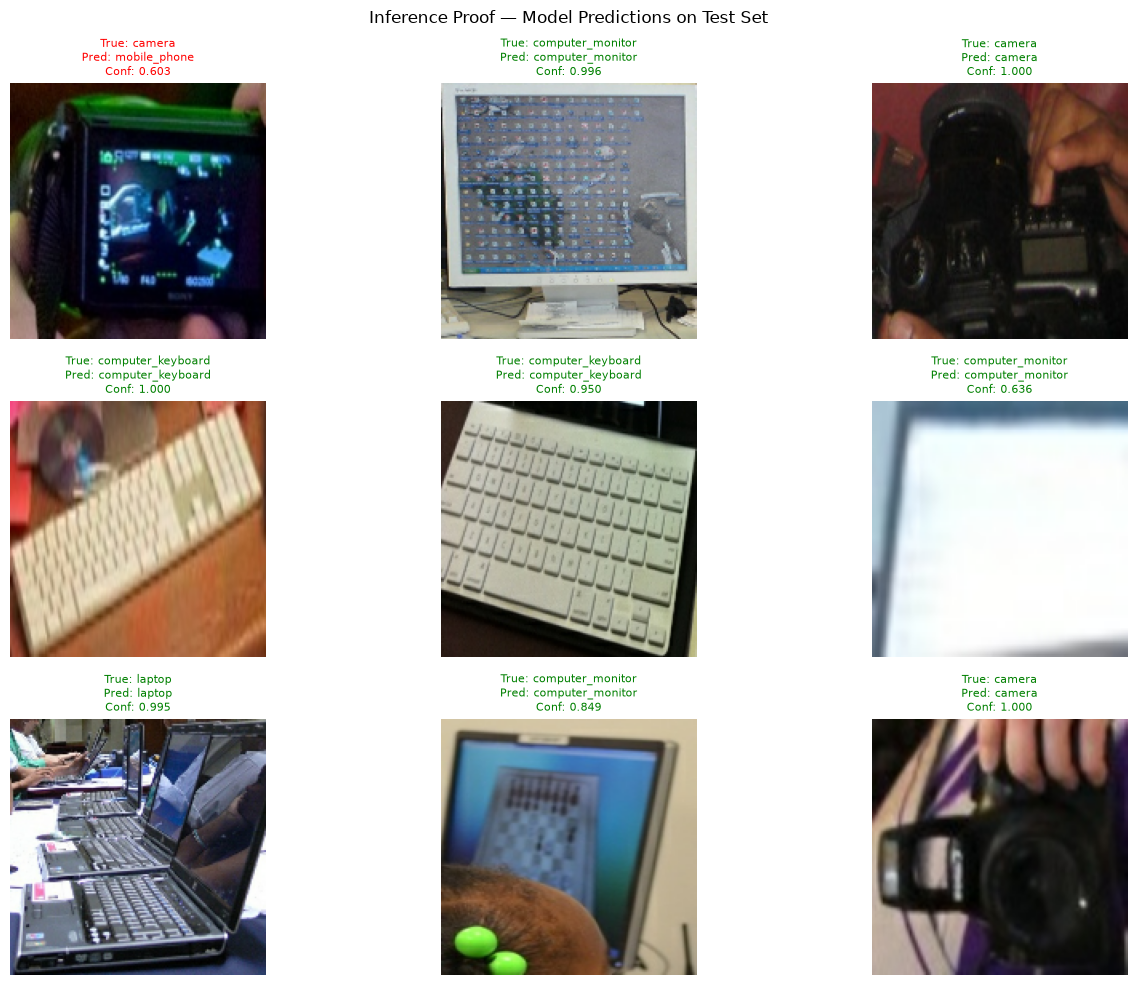

2026-06-24 00:35:02.986341: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,true_label,predicted_label,confidence,correct
0,camera,mobile_phone,0.603446,False
1,computer_monitor,computer_monitor,0.996449,True
2,camera,camera,1.000000,True
3,computer_keyboard,computer_keyboard,0.999991,True
4,computer_keyboard,computer_keyboard,0.949889,True
5,computer_monitor,computer_monitor,0.635994,True
6,laptop,laptop,0.995138,True
7,computer_monitor,computer_monitor,0.849358,True
8,camera,camera,0.999929,True


In [16]:
# Take a batch with diverse classes by shuffling test_ds
shuffled_test = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=123,
).prefetch(AUTOTUNE)

for images, labels in shuffled_test.take(1):
    preds = model.predict(images)
    pred_indices = np.argmax(preds, axis=1)
    true_indices = np.argmax(labels.numpy(), axis=1)
    confidences = np.max(preds, axis=1)

    plt.figure(figsize=(14, 10))
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        color = "green" if pred_indices[i] == true_indices[i] else "red"
        plt.title(
            f"True: {class_names[true_indices[i]]}\n"
            f"Pred: {class_names[pred_indices[i]]}\n"
            f"Conf: {confidences[i]:.3f}",
            fontsize=8,
            color=color,
        )
        plt.axis("off")
    plt.suptitle("Inference Proof — Model Predictions on Test Set", fontsize=12)
    plt.tight_layout()
    plt.savefig(EVALUATION_DIR / "sequential_inference_proof.png", dpi=150)
    plt.show()

# Save inference results
inference_df = pd.DataFrame({
    "true_label": [class_names[i] for i in true_indices[:9]],
    "predicted_label": [class_names[i] for i in pred_indices[:9]],
    "confidence": confidences[:9],
    "correct": [pred_indices[i] == true_indices[i] for i in range(min(9, len(images)))],
})
inference_df.to_csv(EVALUATION_DIR / "sample_inference.csv", index=False)
display(inference_df)

## Kesimpulan

### Ringkasan

Notebook ini telah menjalankan seluruh pipeline klasifikasi gambar aset IT:

1. **Dataset**: 15.000 crop gambar dari Open Images V7, 5 kelas (camera, computer_keyboard, computer_monitor, laptop, mobile_phone).
2. **Split manual**: Dataset dibagi secara eksplisit di notebook ini (80% train / 10% validation / 10% test) dengan source-image grouping untuk mencegah data leakage.
3. **Model**: `tf.keras.Sequential` dengan `Conv2D` dan `MaxPooling2D` eksplisit, menggunakan `EfficientNetV2B0` sebagai feature extractor.
4. **Training**: Model dilatih langsung dengan callback (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau).
5. **Evaluasi**: Akurasi train, validation, dan test dihitung langsung dengan `model.evaluate()`.
6. **Classification report**: Dibuat langsung dari prediksi model pada test set.
7. **Export**: Model yang sama diexport ke SavedModel, TFLite, dan TFJS.
8. **Inference**: Prediksi model pada test set ditampilkan dengan visualisasi.

### Catatan Akurasi

Akurasi minimum wajib Dicoding: **85%**. Target internal: **95%**.

### Revisi dari Submission Sebelumnya

Revisi ini memperbaiki feedback reviewer:
- Split dataset dibuat eksplisit di notebook (tidak lagi memakai flag REUSE_EXISTING_SPLIT).
- Model final adalah Sequential dengan Conv2D dan Pooling Layer eksplisit.
- Model benar-benar dilatih langsung (tidak ada shortcut REUSE_EXISTING_WEIGHTS).
- Test accuracy dihitung langsung dengan `model.evaluate(test_ds)`.
- Classification report dibuat langsung dari prediksi `test_ds`.
- Model yang diexport adalah model yang sama dengan model yang dievaluasi.